# Convolutional Neural Networks - Build Model
---
In this notebook, we build and train a **CNN** to classify images from the CIFAR-10 database. 
* The code provided here are **almost** working. You are required to build up a CNN model and train it.
* Make sure you covered implementations of the **TODO**s in this notebook

The images in this database are small color images that fall into one of ten classes; some example images are pictured below.

<img src='cifar_data.png' width=50% height=50% />

### Optional: Use [CUDA](http://pytorch.org/docs/stable/cuda.html) if Available

Since these are color (32x32x3) images, it may prove useful to speed up your training time by using a GPU. CUDA is a parallel computing platform and CUDA Tensors are the same as typical Tensors, but they utilize GPU's for effcient parallel computation.

In [1]:
import torch
import numpy as np

# check if CUDA is available
train_on_gpu = torch.cuda.is_available()

if not train_on_gpu:
    print('CUDA is not available.  Training on CPU ...')
else:
    print('CUDA is available!  Training on GPU ...')

CUDA is available!  Training on GPU ...


## Load the [Data](http://pytorch.org/docs/stable/torchvision/datasets.html)
---
Downloading may take a minute. We load in the training and test data, split the training data into a training and validation set, then create DataLoaders for each of these sets of data.

In [2]:
from torchvision import datasets
import torchvision.transforms as transforms
from torch.utils.data.sampler import SubsetRandomSampler


# number of subprocesses to use for data loading
num_workers = 8
# how many samples per batch to load
batch_size = 32
# percentage of training set to use as validation
valid_size = 0.2

# convert data to a normalized torch.FloatTensor
train_transform = transforms.Compose([                      # chain training transforms
    transforms.RandomCrop(32, padding=4),                   # random crop with padding
    transforms.RandomHorizontalFlip(),                      # random left-right flip
    transforms.RandomAffine(degrees=0, translate=(0.1,0.1), scale=(0.9,1.1)),  # small move/zoom
    transforms.ToTensor(),                                  # PIL -> tensor
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5)),      # normalize
    transforms.RandomErasing(p=0.25, scale=(0.02,0.2), ratio=(0.3,3.3))        # random erasing
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

# choose the training and test datasets
train_data = datasets.CIFAR10('data', train=True,
                              download=True, transform=train_transform)
valid_data = datasets.CIFAR10('data', train=True,
                              download=False, transform=test_transform)
test_data = datasets.CIFAR10('data', train=False,
                             download=True, transform=test_transform)

# obtain training indices that will be used for validation
num_train = len(train_data)
indices = list(range(num_train))
np.random.shuffle(indices)
split = int(np.floor(valid_size * num_train))
train_idx, valid_idx = indices[split:], indices[:split]

# define samplers for obtaining training and validation batches
train_sampler = SubsetRandomSampler(train_idx)
valid_sampler = SubsetRandomSampler(valid_idx)

# prepare data loaders (combine dataset and sampler)
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size,
    sampler=train_sampler, num_workers=num_workers)
valid_loader = torch.utils.data.DataLoader(valid_data, batch_size=batch_size, 
    sampler=valid_sampler, num_workers=num_workers)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, 
    num_workers=num_workers)

# specify the image classes
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

### Visualize a Batch of Training Data

In [3]:
import matplotlib.pyplot as plt
%matplotlib inline

# helper function to un-normalize and display an image
def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    plt.imshow(np.transpose(img, (1, 2, 0)))  # convert from Tensor image

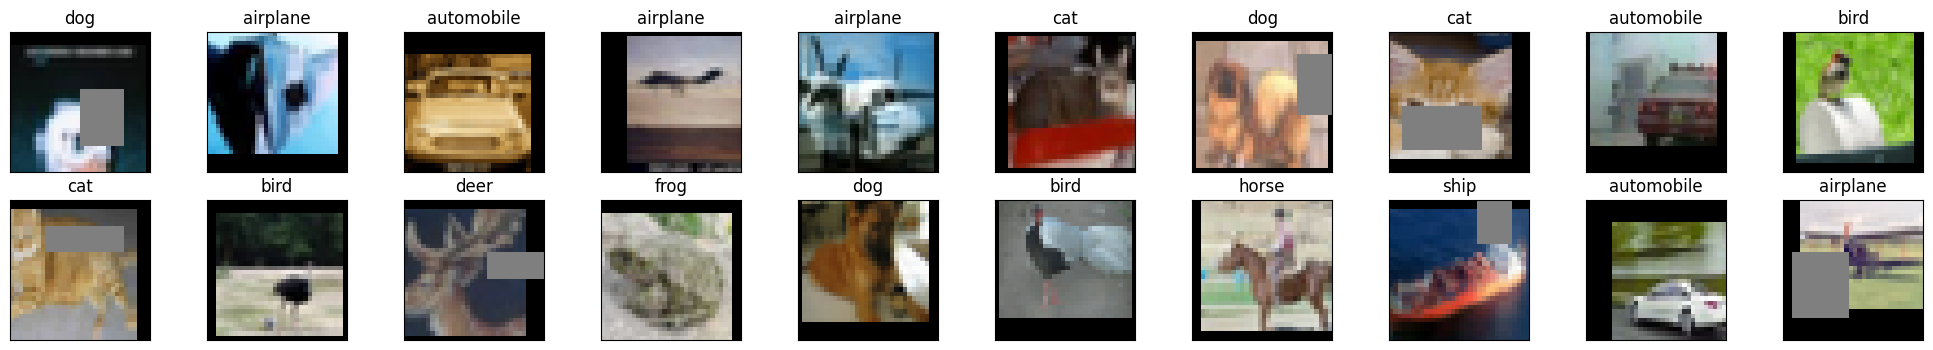

In [4]:
# obtain one batch of training images
dataiter = iter(train_loader)
#images, labels = dataiter.next() #python, torchvision version match issue
images, labels = next(dataiter)
images = images.numpy() # convert images to numpy for display

# plot the images in the batch, along with the corresponding labels
fig = plt.figure(figsize=(25, 4))
# display 20 images
for idx in np.arange(20):
    ax = fig.add_subplot(2, int(20/2), idx+1, xticks=[], yticks=[])
    imshow(images[idx])
    ax.set_title(classes[labels[idx]])

### View an Image in More Detail

Here, we look at the normalized red, green, and blue (RGB) color channels as three separate, grayscale intensity images.

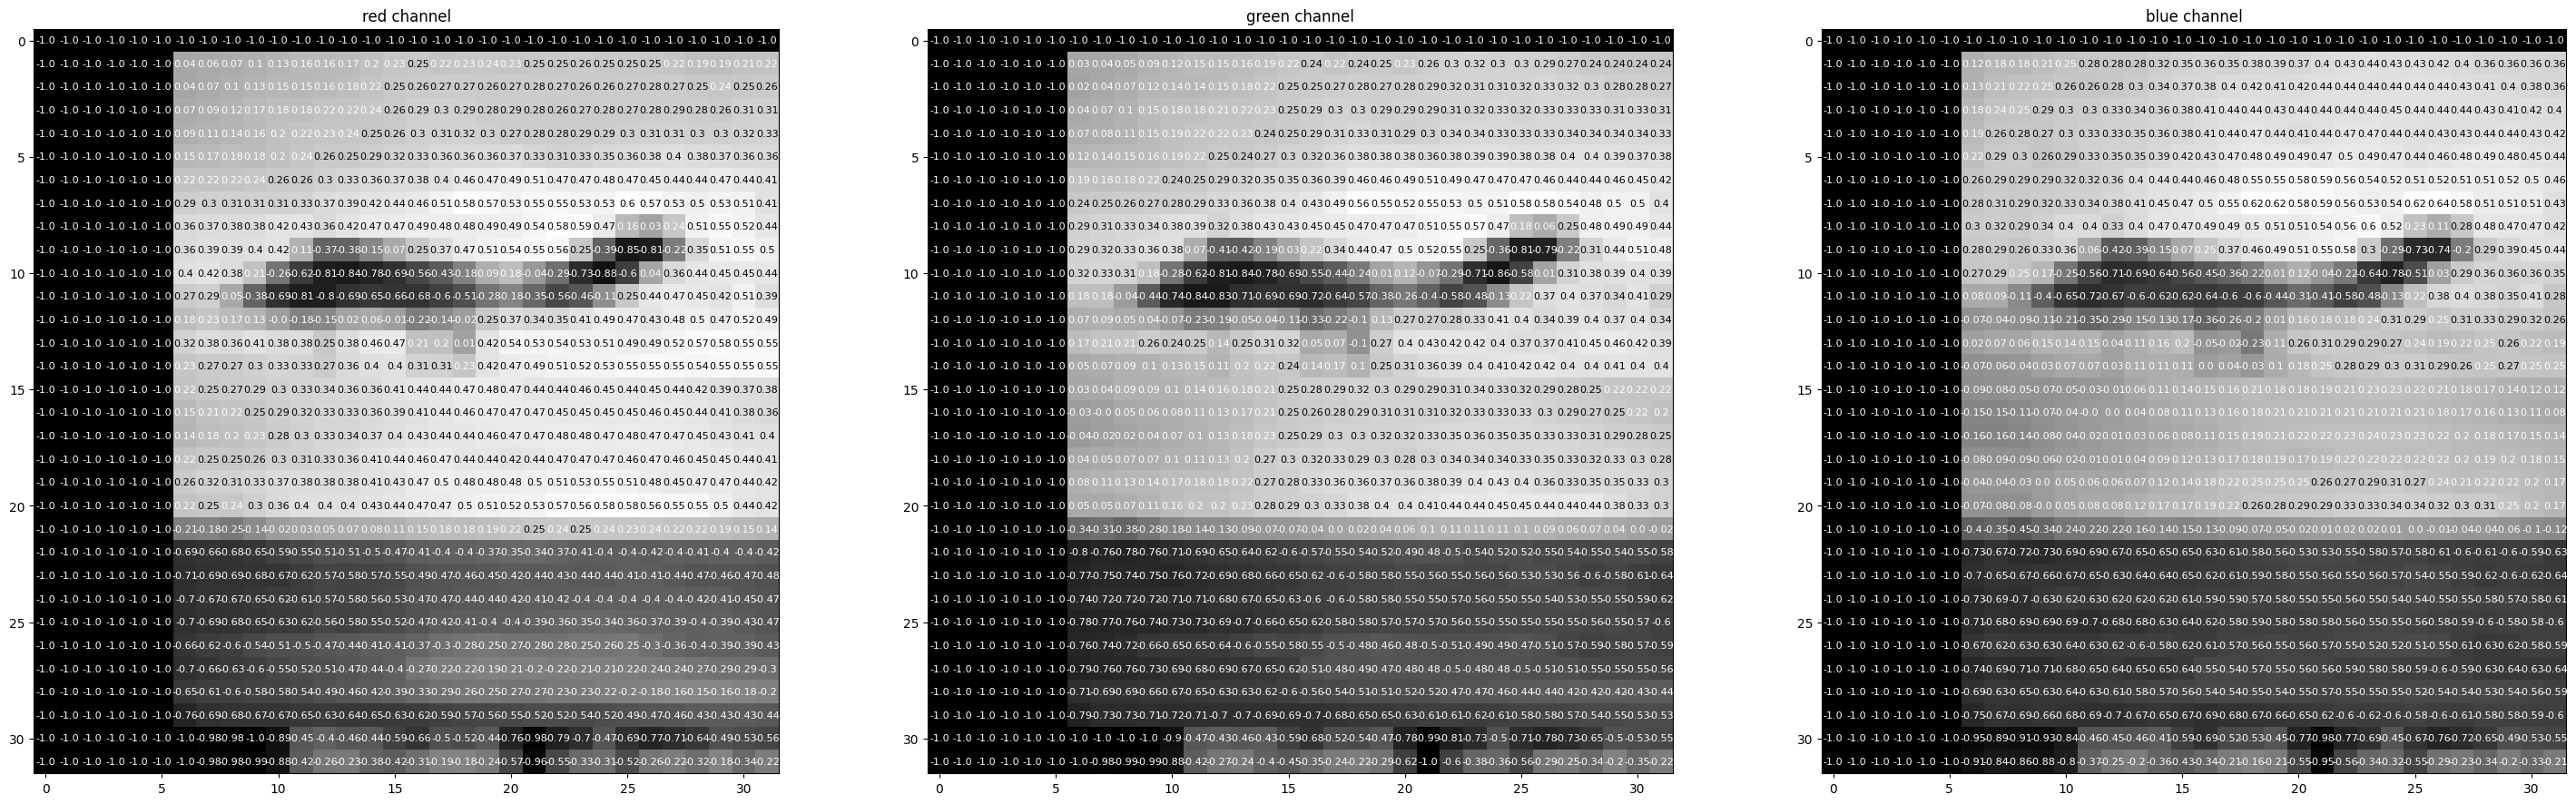

In [5]:
rgb_img = np.squeeze(images[3])
channels = ['red channel', 'green channel', 'blue channel']

fig = plt.figure(figsize = (36, 36)) 
for idx in np.arange(rgb_img.shape[0]):
    ax = fig.add_subplot(1, 3, idx + 1)
    img = rgb_img[idx]
    ax.imshow(img, cmap='gray')
    ax.set_title(channels[idx])
    width, height = img.shape
    thresh = img.max()/2.5
    for x in range(width):
        for y in range(height):
            val = round(img[x][y],2) if img[x][y] !=0 else 0
            ax.annotate(str(val), xy=(y,x),
                    horizontalalignment='center',
                    verticalalignment='center', size=8,
                    color='white' if img[x][y]<thresh else 'black')

## **TODO**: Define the Network [Architecture](http://pytorch.org/docs/stable/nn.html)
---
Build up your own Convolutional Neural Network using Pytorch API:
- nn.Conv2d(): for convolution
- nn.MaxPool2d(): for maxpooling (spatial resolution reduction)
- nn.Linear(): for last 1 or 2 layers of fully connected layer before the output layer.
- nn.Dropout(): optional, [dropout](https://pytorch.org/docs/stable/generated/torch.nn.Dropout.html) can be used to avoid overfitting.
- F.relu(): Use ReLU as the activation function for all the hidden layers

The following is a skeleton example that's not completely working. 

In [6]:
import torch.nn as nn
import torch.nn.functional as F

# define the CNN architecture
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        
        # TOTO: Build multiple convolutional layers (sees 32x32x3 image tensor in the first hidden layer)
                # for example, conv1, conv2 and conv3
        self.conv1 = nn.Conv2d(3, 12, 5, padding=1)
        self.bn1 = nn.BatchNorm2d(12)

        self.conv2 = nn.Conv2d(12, 24, 3)
        self.bn2 = nn.BatchNorm2d(24)

        self.conv3 = nn.Conv2d(24, 48, 5, padding=1)
        self.bn3 = nn.BatchNorm2d(48)

        self.conv4 = nn.Conv2d(48, 96, 3)
        self.bn4 = nn.BatchNorm2d(96)

        self.conv5 = nn.Conv2d(96, 192, 3)
        self.bn5 = nn.BatchNorm2d(192)

        self.conv6 = nn.Conv2d(192, 384, 3)
        self.bn6 = nn.BatchNorm2d(384)

        
        # max pooling layer
        self.pool = nn.MaxPool2d(2, 2)
        
        # for example, fc1 and fc2
        self.fc1 = nn.Linear(384*4*4, 512)  # fully connected: flattened conv output -> hidden units
        self.fc2 = nn.Linear(512, 10)  # fully connected: hidden units -> 10 class scores
        pass

        # TODO: dropout layer (p=0.25, you can adjust)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))

        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool(F.relu(self.bn4(self.conv4(x))))

        x = F.relu(self.bn5(self.conv5(x)))
        x = self.pool(F.relu(self.bn6(self.conv6(x))))

        
        # TODO: flatten x at this point to get it ready to feed into the fully connected layer(s)
        # Can use this but need to figure out the actual value for a, b and c
        # x = x.view(-1, a * b * c)
        x = x.view(x.size(0), -1)  # flatten: keep batch dimension, flatten the rest


        # optional add dropout layer
        x = self.dropout(x)
        
        # add 1st hidden layer, with relu activation function
        x = F.relu(self.fc1(x))
        # optional add dropout layer
        x = self.dropout(x)
        # add 2nd hidden layer, with relu activation function
        x = self.fc2(x)
        return x

# create a complete CNN
model = Net()
print(model)

# move tensors to GPU if CUDA is available
if train_on_gpu:
    model.cuda()

Net(
  (conv1): Conv2d(3, 12, kernel_size=(5, 5), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(12, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(12, 24, kernel_size=(3, 3), stride=(1, 1))
  (bn2): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(24, 48, kernel_size=(5, 5), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(48, 96, kernel_size=(3, 3), stride=(1, 1))
  (bn4): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv5): Conv2d(96, 192, kernel_size=(3, 3), stride=(1, 1))
  (bn5): BatchNorm2d(192, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1))
  (bn6): BatchNorm2d(384, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dil

### Specify [Loss Function](http://pytorch.org/docs/stable/nn.html#loss-functions) and [Optimizer](http://pytorch.org/docs/stable/optim.html)
---
Decide on a loss and optimization function that is best suited for this classification task. The linked code examples from above, may be a good starting point; [this PyTorch classification example](https://github.com/pytorch/tutorials/blob/master/beginner_source/blitz/cifar10_tutorial.py) Pay close attention to the value for **learning rate** as this value determines how your model converges to a small error.

The following is working code, but you can make your own adjustments.

**TODO**: try to compare with ADAM optimizer

In [7]:
import torch.optim as optim

# specify loss function (categorical cross-entropy)
criterion = nn.CrossEntropyLoss()

# specify optimizer
optimizer = optim.SGD(       # create SGD optimizer
    model.parameters(),      # parameters to optimize
    lr=0.025,                  # initial learning rate
    momentum=0.9,            # momentum term
    weight_decay=5e-4        # L2 regularization
)

# number of epochs to train the model
n_epochs = 250

scheduler = optim.lr_scheduler.CosineAnnealingLR(  # cosine decay scheduler
    optimizer,                                     # optimizer to control
    T_max=n_epochs                                 # total epochs before LR reaches minimum
)



## Train the Network
---
Remember to look at how the training and validation loss decreases over time; if the validation loss ever increases it indicates possible overfitting.

The following is working code, but you are encouraged to make your own adjustments and enhance the implementation.

In [ ]:
valid_loss_min = np.inf # track change in validation loss

### Plotting ###
train_losses = []   # store avg training loss per epoch
valid_losses = []   # store avg validation loss per epoch
lrs = []            # store learning rate per epoch

for epoch in range(1, n_epochs+1):

    # keep track of training and validation loss
    train_loss = 0.0
    valid_loss = 0.0
    
    ###################
    # train the model #
    ###################
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        # move tensors to GPU if CUDA is available
        if train_on_gpu:
            data = data.cuda(non_blocking=True)
            target = target.cuda(non_blocking=True)
        # clear the gradients of all optimized variables
        optimizer.zero_grad()
        # forward pass: compute predicted outputs by passing inputs to the model
        output = model(data)
        # calculate the batch loss
        loss = criterion(output, target)
        # backward pass: compute gradient of the loss with respect to model parameters
        loss.backward()
        # perform a single optimization step (parameter update)
        optimizer.step()
        # update training loss
        train_loss += loss.item()*data.size(0)
        
    ######################    
    # validate the model #
    ######################
    model.eval()

    for batch_idx, (data, target) in enumerate(valid_loader):
        # move tensors to GPU if CUDA is available
        if train_on_gpu:
            data = data.cuda(non_blocking=True)
            target = target.cuda(non_blocking=True)
        # forward pass: compute predicted outputs by passing inputs to the model
        output = model(data)
        # calculate the batch loss
        loss = criterion(output, target)
        # update average validation loss 
        valid_loss += loss.item()*data.size(0)  
    
    # calculate average losses
    train_loss = train_loss/len(train_loader.sampler)
    valid_loss = valid_loss/len(valid_loader.sampler)
    
    ### PLOTTING ###
    train_losses.append(train_loss)   # save training loss
    valid_losses.append(valid_loss)   # save validation loss
    lrs.append(optimizer.param_groups[0]["lr"])         # save current lr
    
    # update learning rate once per epoch
    scheduler.step()
        
    # print training/validation statistics 
    print('Epoch: {} \tTraining Loss: {:.6f} \tValidation Loss: {:.6f}'.format(
        epoch, train_loss, valid_loss))
    
    # save model if validation loss has decreased
    if valid_loss <= valid_loss_min:
        print('Validation loss decreased ({:.6f} --> {:.6f}).  Saving model ...'.format(
        valid_loss_min,
        valid_loss))
        torch.save(model.state_dict(), 'model_trained.pt')
        valid_loss_min = valid_loss
        
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(8, 6))                      # left axis (loss)
ax1.plot(train_losses, label='Training Loss')                # loss curve
ax1.plot(valid_losses, label='Validation Loss')              # loss curve
ax1.set_xlabel('Epoch')                                      # x label
ax1.set_ylabel('Loss')                                       # left y label
ax1.grid(True)                                               # grid

ax2 = ax1.twinx()                                            # right axis (lr)
ax2.plot(lrs, linestyle=':', color='purple', label='Learning Rate') # lr curve
ax2.set_ylabel('Learning Rate')                              # right y label

lines1, labels1 = ax1.get_legend_handles_labels()            # loss legend items
lines2, labels2 = ax2.get_legend_handles_labels()            # lr legend items
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')   # combined legend

plt.title('Training/Validation Loss + Learning Rate')        # title
plt.savefig("loss_curve.png", dpi=300, bbox_inches="tight")  # save
plt.show()                                                   # display

Epoch: 1 	Training Loss: 2.289177 	Validation Loss: 2.303984
Validation loss decreased (inf --> 2.303984).  Saving model ...
Epoch: 2 	Training Loss: 2.298783 	Validation Loss: 2.129741
Validation loss decreased (2.303984 --> 2.129741).  Saving model ...
Epoch: 3 	Training Loss: 2.101284 	Validation Loss: 1.903514
Validation loss decreased (2.129741 --> 1.903514).  Saving model ...
Epoch: 4 	Training Loss: 1.922837 	Validation Loss: 1.690841
Validation loss decreased (1.903514 --> 1.690841).  Saving model ...
Epoch: 5 	Training Loss: 1.790962 	Validation Loss: 1.602175
Validation loss decreased (1.690841 --> 1.602175).  Saving model ...
Epoch: 6 	Training Loss: 1.638351 	Validation Loss: 1.334181
Validation loss decreased (1.602175 --> 1.334181).  Saving model ...
Epoch: 7 	Training Loss: 1.471954 	Validation Loss: 1.249186
Validation loss decreased (1.334181 --> 1.249186).  Saving model ...
Epoch: 8 	Training Loss: 1.357660 	Validation Loss: 1.102093
Validation loss decreased (1.24918

###  Load the Model with the Lowest Validation Loss
This is the model we will use for testing, which is the model we saved in the last step

In [ ]:
model.load_state_dict(torch.load('model_trained.pt'))

## Test the Trained Network
---
Test your trained model on previously unseen data! Remember we have downloaded `train_data` and `test_data`. We will use `test_data` through `test_loader`.

A "good" result will be a CNN that gets around 70% (or more, try your best!) accuracy on these test images.

The following is working code, but you are encouraged to make your own adjustments and enhance the implementation.

In [ ]:
# track test loss
test_loss = 0.0
class_correct = list(0. for i in range(10))
class_total = list(0. for i in range(10))

model.eval()
# iterate over test data
for batch_idx, (data, target) in enumerate(test_loader):
    # move tensors to GPU if CUDA is available
    if train_on_gpu:
        data, target = data.cuda(), target.cuda()
    # forward pass: compute predicted outputs by passing inputs to the model
    output = model(data)
    # calculate the batch loss
    loss = criterion(output, target)
    # update test loss 
    test_loss += loss.item()*data.size(0)
    # convert output probabilities to predicted class
    _, pred = torch.max(output, 1)    
    # compare predictions to true label
    correct_tensor = pred.eq(target.data.view_as(pred))
    correct = np.squeeze(correct_tensor.numpy()) if not train_on_gpu else np.squeeze(correct_tensor.cpu().numpy())
    # calculate test accuracy for each object class
    for i in range(target.size(0)):
        label = target.data[i]
        class_correct[label] += correct[i].item()
        class_total[label] += 1

# average test loss
test_loss = test_loss/len(test_loader.dataset)
print('Test Loss: {:.6f}\n'.format(test_loss))

for i in range(10):
    if class_total[i] > 0:
        print('Test Accuracy of %5s: %2d%% (%2d/%2d)' % (
            classes[i], 100 * class_correct[i] / class_total[i],
            np.sum(class_correct[i]), np.sum(class_total[i])))
    else:
        print('Test Accuracy of %5s: N/A (no training examples)' % (classes[i]))

print('\nTest Accuracy (Overall): %2d%% (%2d/%2d)' % (
    100. * np.sum(class_correct) / np.sum(class_total),
    np.sum(class_correct), np.sum(class_total)))

### Visualize Sample Test Results

The following is working code, but you are encouraged to make your own adjustments and enhance the visualization.

In [ ]:

# obtain one batch of test images
dataiter = iter(test_loader)
images, labels = next(dataiter)

# move model inputs to cuda, if GPU available
if train_on_gpu:
    images = images.cuda()
    labels = labels.cuda()  # keep labels on same device for comparisons

# get sample outputs
with torch.no_grad():               
    output = model(images)

# convert output probabilities to predicted class
_, preds_tensor = torch.max(output, 1)

#  move preds to CPU before numpy
preds = np.squeeze(preds_tensor.detach().cpu().numpy())

#  make images a CPU tensor for plotting / imshow
images_cpu = images.detach().cpu()
labels_cpu = labels.detach().cpu()

# plot the images in the batch, along with predicted and true labels
fig = plt.figure(figsize=(25, 4))
for idx in np.arange(20):
    ax = fig.add_subplot(2, int(20/2), idx+1, xticks=[], yticks=[])
    imshow(images_cpu[idx])  # (5) plot CPU tensor, not CUDA tensor
    ax.set_title("{} ({})".format(classes[preds[idx]], classes[labels_cpu[idx]]),
                 color=("green" if preds[idx] == labels_cpu[idx].item() else "red"))

In [ ]:
import torch                                
import torch.nn.functional as F             
import numpy as np                          
import matplotlib.pyplot as plt             
import matplotlib.gridspec as gridspec

# =============================================================================
# TASK 2: FEATURE MAP VISUALIZATION
# =============================================================================

# -----------------------------------------------------------------------------
# (SETUP) device + eval mode
# -----------------------------------------------------------------------------
use_cuda = torch.cuda.is_available()        
try:
    use_cuda = use_cuda and train_on_gpu    
except NameError:
    pass

device = torch.device("cuda" if use_cuda else "cpu")   
model = model.to(device)                               
model.eval()                                           

# -----------------------------------------------------------------------------
# 
# -----------------------------------------------------------------------------
def unnormalize(img_chw):                               
    return (img_chw * 0.5 + 0.5).clamp(0, 1)            
##
# -----------------------------------------------------------------------------
# simple display helper for a single image tensor [C,H,W]
# -----------------------------------------------------------------------------
def show_image(img_chw, title=""):                      
    img = unnormalize(img_chw)                          # undo normalization
    img_hwc = img.permute(1, 2, 0).cpu().numpy()        # CHW -> HWC, move to numpy
    plt.imshow(img_hwc)                                 # show with matplotlib
    plt.title(title)                                    
    plt.axis("off")                                     

# -----------------------------------------------------------------------------
# feature-map normalization for display
# -----------------------------------------------------------------------------
def normalize_fmap_for_display(fmap_hw):                
    fmin = fmap_hw.min()                                
    fmax = fmap_hw.max()                                
    if (fmax - fmin) < 1e-8:                            
        return torch.zeros_like(fmap_hw)                
    return (fmap_hw - fmin) / (fmax - fmin)             # scale to [0,1]

In [ ]:
# =============================================================================
# PART A: Feature Maps from the First Convolutional Layer
# =============================================================================

# -----------------------------------------------------------------------------
# (A1) Select 3 test images from different classes
# -----------------------------------------------------------------------------
picked = []                                             
picked_labels = set()                                   

for i in range(len(test_data)):                         
    img, y = test_data[i]                               
    if y not in picked_labels:                          
        picked.append((img, y))                         
        picked_labels.add(y)                            
    if len(picked) == 3:                                
        break

# -----------------------------------------------------------------------------
# (A2) Pass each image through the CNN up to the first conv layer output
# -----------------------------------------------------------------------------
def forward_to_conv1_relu(model, x):                    
    x = model.conv1(x)                                  
    x = model.bn1(x)                                    
    x = F.relu(x)                                       
    return x                                            

# -----------------------------------------------------------------------------
# (A3) Visualize at least 8 feature maps per image (+ original image)
# -----------------------------------------------------------------------------
# display normalization (min-max to [0,1])
def norm01(t2d: torch.Tensor) -> torch.Tensor:
    tmin = t2d.min()
    tmax = t2d.max()
    if (tmax - tmin) < 1e-8:
        return torch.zeros_like(t2d)
    return (t2d - tmin) / (tmax - tmin)

for img_chw, y in picked:
    x = img_chw.unsqueeze(0).to(device)

    with torch.no_grad():
        fmap = model.conv1(x)
        fmap = model.bn1(fmap)
        fmap = F.relu(fmap)
        fmap = fmap[0].detach().cpu()
        W = model.conv1.weight.detach().cpu()

    n_maps = min(12, fmap.shape[0])

    fig = plt.figure(figsize=(22, 14))
    fig.suptitle(f"Part A: conv1 feature maps + kernels | True class: {classes[y]}", fontsize=14)

    gs = gridspec.GridSpec(
        nrows=4, ncols=8, figure=fig,
        height_ratios=[1.2, 1.0, 1.0, 1.0],
        hspace=0.35, wspace=0.25
    )

    ax_in = fig.add_subplot(gs[0, 0:4])
    plt.sca(ax_in)
    show_image(img_chw, title=f"input | class: {classes[y]}")
    ax_in.axis("off")

    channel_names = ["R", "G", "B"]

    img_cpu = img_chw.detach().cpu()
    for ch in range(3):
        ax_rgb = fig.add_subplot(gs[0, 4 + ch])
        ch_img = norm01(img_cpu[ch])              
        ax_rgb.imshow(ch_img.numpy(), cmap="gray")
        ax_rgb.set_title(channel_names[ch], fontsize=10)
        ax_rgb.axis("off")

    for k in range(n_maps):
        r = 1 + (k // 4)
        c = (k % 4)

        ax_fm = fig.add_subplot(gs[r, 2*c])
        fm = norm01(fmap[k])
        ax_fm.imshow(fm.numpy(), cmap="gray")
        ax_fm.set_title(f"fmap {k}", fontsize=10)
        ax_fm.axis("off")

        gs_k = gs[r, 2*c + 1].subgridspec(3, 1, hspace=0.05)

        for ch in range(3):
            ax_kw = fig.add_subplot(gs_k[ch, 0])
            kw = norm01(W[k, ch])
            ax_kw.imshow(kw.numpy(), cmap="gray")

            ax_kw.text(
                -0.15, 0.5,
                channel_names[ch],
                transform=ax_kw.transAxes,
                va="center",
                ha="right",
                fontsize=10,
                fontweight="bold"
            )

            ax_kw.axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
# =============================================================================
# PART B: Maximally Activating Images for Selected Filters 
# =============================================================================

# (B1) Choose one conv layer and select 3 filters
chosen_layer_name = "conv2"                              
chosen_filters = [0, 1, 2]                               
top_k = 5                                                


# (B2) Define "activation" scalar for a filter on an image

def forward_to_conv2_relu(model, x):                     
    x = F.relu(model.bn1(model.conv1(x)))                
    x = F.relu(model.bn2(model.conv2(x)))                
    return x                                             

# (B3) Scan the test set and keep the top 5 images for each chosen filter

top_results = {f: [] for f in chosen_filters}            

with torch.no_grad():                                    
    for images, labels in test_loader:                   
        images_cpu = images.detach().cpu()               
        labels_cpu = labels.detach().cpu()               

        images = images.to(device, non_blocking=True)    

        fmap2 = forward_to_conv2_relu(model, images)     
        fmap2_cpu = fmap2.detach().cpu()                 

        for bi in range(fmap2_cpu.shape[0]):             
            true_label = int(labels_cpu[bi].item())      
            img_chw = images_cpu[bi]                     

            for f in chosen_filters:                     
                score = float(fmap2_cpu[bi, f].mean().item())  

                cur = top_results[f]                     
                if len(cur) < top_k:
                    cur.append((score, img_chw, true_label))
                    cur.sort(key=lambda t: t[0], reverse=True)
                else:
                    if score > cur[-1][0]:
                        cur[-1] = (score, img_chw, true_label)
                        cur.sort(key=lambda t: t[0], reverse=True)

                        
# (B4) Visualize the 12 conv2 kernels 

W2 = model.conv2.weight.detach().cpu()   

def norm01_2d(t2d):                      # min-max normalize 2D tensor -> [0,1]
    tmin = t2d.min()
    tmax = t2d.max()
    if (tmax - tmin) < 1e-8:
        return torch.zeros_like(t2d)
    return (t2d - tmin) / (tmax - tmin)

for f in chosen_filters:                                 
    results = top_results[f]                             

    fig = plt.figure(figsize=(18, 7))                    
    fig.suptitle(
        f"Part B: conv2 | Filter {f} | kernels (12) + Top {top_k} images | activation = mean(ReLU(map))"
    )

    gs = gridspec.GridSpec(2, 1, height_ratios=[1.2, 1.0], hspace=0.35)

  
    # TOP: 12 kernels for this filter 

    gs_k = gs[0].subgridspec(1, 12, wspace=0.05, hspace=0.20)

    for c in range(12):                                  # c = input-channel index into conv2
        axk = fig.add_subplot(gs_k[0, c])

        ker = W2[f, c]                                   # one 3x3 kernel: [3,3]
        ker_disp = norm01_2d(ker)                         # normalize for display

        axk.imshow(ker_disp.numpy(), cmap="gray")
        axk.set_title(f"in{c}", fontsize=8)              # label which input channel kernel this is
        axk.axis("off")


    # BOTTOM: top 5 test images for this filter

    gs_i = gs[1].subgridspec(1, top_k, wspace=0.15)

    for i, (score, img_chw, y) in enumerate(results):
        axi = fig.add_subplot(gs_i[0, i])
        plt.sca(axi)                                     
        show_image(img_chw, title=f"{classes[y]}\n{score:.3f}")
        axi.axis("off")

    plt.tight_layout()
    plt.show()